# Spike Mass Parameter Sweep

This notebook studies how the total mass of the CDM spike changes the SMBH hardening history. For each value of `M_spike`, the binary is evolved with the same initial separation and the final separation is compared across runs.

The diagnostic quantity is the SMBH separation as a function of time. A lower final separation means that the CDM spike extracted more orbital energy before becoming depleted.

Scanned parameter: total CDM spike mass, expressed as a fraction of the primary SMBH mass.


# Imports and Global Parameters

Define the binary, units, integration time, Schwarzschild radius, and the array of parameter values used in the sweep.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import trange

from cdm_spike_utils import (
    add_volume_uniform_spike,
    apply_publication_style,
    configure_smbh_collisions,
    create_smbh_binary,
    moving_average,
    plot_parameter_sweep,
    plot_spike_3d,
    schwarzschild_radius_au,
    separation_history,
)

# Define the SMBH binary parameters.
M_1 = 3e9
q = 1
M_2 = q * M_1
M_total = M_1 + M_2
R_sch = schwarzschild_radius_au(M_1)
print(f"The Schwarzschild radius is {R_sch} AU")

# Simulation parameters.
N_years = 20000
N_frames = 600
t_array = np.linspace(0, N_years, N_frames)
Delta_time = N_years / N_frames
N_masses = 100
M_spike = np.linspace(0.01, 1.6, N_masses) * M_1
N_particles = 80
radius_spike = 400000
avg_distance_tot = []


The Schwarzschild radius is 59.238711673042346 AU


# Run the Sweep

For each parameter value, a new `rebound` simulation is initialized. The CDM particles are generated with the same random seed so differences between curves mainly reflect the scanned parameter rather than a different random realization.


Processing:   0%|          | 0/100 [00:00<?, ?it/s]

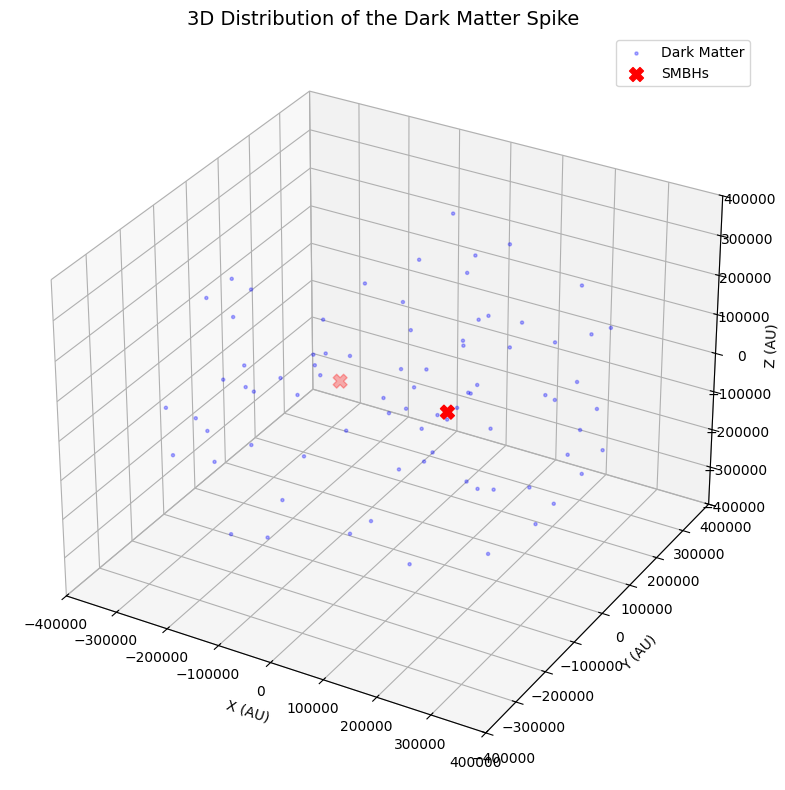

Processing:   1%|          | 1/100 [00:03<06:35,  3.99s/it]

Simulation for M_spike=3.000e+07 Msun completed


Processing:   2%|▏         | 2/100 [00:06<05:18,  3.25s/it]

Simulation for M_spike=7.818e+07 Msun completed


Processing:   3%|▎         | 3/100 [00:10<05:38,  3.49s/it]

...

Simulation for M_spike=4.704e+09 Msun completed


Processing:  99%|█████████▉| 99/100 [07:17<00:06,  6.26s/it]

Simulation for M_spike=4.752e+09 Msun completed


Processing: 100%|██████████| 100/100 [07:24<00:00,  4.45s/it]

Simulation for M_spike=4.800e+09 Msun completed


In [2]:
for m in trange(len(M_spike), desc="Processing"):
    sim, black_hole_1, black_hole_2, M_2, M_total = create_smbh_binary(M_1, q=q)

    M_spike_total = M_spike[m]
    m_single_dm = add_volume_uniform_spike(
        sim,
        n_particles=N_particles,
        total_spike_mass=M_spike_total,
        m_central=M_total,
        r_min=1000,
        r_max=radius_spike,
        seed=0,
    )

    if m == 0:
        plot_spike_3d(sim, output_path=f'DM_distribution_N_CDM={N_masses}_uniformdistrib.pdf')
        plt.show()

    configure_smbh_collisions(sim, R_sch, softening=True)
    bh_distance = separation_history(sim, black_hole_1, black_hole_2, N_frames, Delta_time)
    avg_distance_tot.append(moving_average(bh_distance, window=50))

    print(f'Simulation for M_spike={M_spike_total:.3e} Msun completed')


# Plot Separation Curves

The color of each curve encodes the scanned parameter. The late-time value of each curve gives the stalling distance for that run.


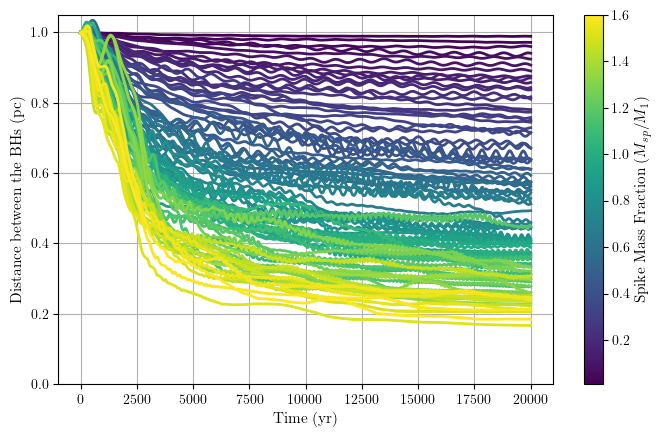

In [3]:
apply_publication_style(use_tex=True)

fig1, ax1d = plot_parameter_sweep(
    t_array=t_array,
    distance_histories=avg_distance_tot,
    parameter_values=M_spike / M_1,
    colorbar_label='Spike Mass Fraction ($M_{sp} / M_1$)',
    cmap_name='viridis',
    output_path=f'Distance_vs_time_scanning_Mspike_N={N_particles}_Nscanning={N_masses}_softened2.pdf',
)

plt.show()


# Save Numerical Results

Store the separation histories in a compressed NumPy file so they can be reused for fitting or plotting without rerunning the full sweep.


In [4]:
np.savez(f'distance_vs_time_sweep_spike_mass_N={N_particles}_Nsweep={N_masses}_softened.npz', avg_distance_tot = avg_distance_tot)
